In [ ]:
from google.colab import files
uploaded = files.upload()

Saving breast_cancer_unclean_v2.csv to breast_cancer_unclean_v2.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("breast_cancer_unclean_v2.csv", header=None)
print("Shape:", df.shape)
df.head()

print(df.info())
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Shape: (711, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 711 entries, 0 to 710
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       711 non-null    object
 1   1       711 non-null    object
 2   2       711 non-null    object
 3   3       711 non-null    object
 4   4       711 non-null    object
 5   5       711 non-null    object
 6   6       711 non-null    object
 7   7       711 non-null    object
 8   8       711 non-null    object
 9   9       711 non-null    object
 10  10      711 non-null    object
dtypes: object(11)
memory usage: 61.2+ KB
None

Missing values:
 0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
dtype: int64

Duplicates: 14


In [ ]:
columns = [
    "Sample_Code_Number",
    "Clump_Thickness",
    "Uniformity_Cell_Size",
    "Uniformity_Cell_Shape",
    "Marginal_Adhesion",
    "Single_Epithelial_Cell_Size",
    "Bare_Nuclei",
    "Bland_Chromatin",
    "Normal_Nucleoli",
    "Mitoses",
    "Class"
]

df.columns = columns

In [ ]:
df.replace('?', np.nan, inplace=True)

print(df.isnull().sum())

Sample_Code_Number             32
Clump_Thickness                33
Uniformity_Cell_Size           37
Uniformity_Cell_Shape          31
Marginal_Adhesion              40
Single_Epithelial_Cell_Size    38
Bare_Nuclei                    51
Bland_Chromatin                41
Normal_Nucleoli                30
Mitoses                        40
Class                          43
dtype: int64


In [ ]:
# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')

In [ ]:
# Fill missing values using median
df.fillna(df.median(), inplace=True)

In [ ]:
# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (693, 11)


In [ ]:
# Convert class labels
df["Class"] = df["Class"].map({2: 0, 4: 1})

In [ ]:
df.drop("Sample_Code_Number", axis=1, inplace=True)

In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
model = DecisionTreeClassifier(criterion='gini', random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8848920863309353

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.94      0.92        95
           1       0.85      0.77      0.81        44

    accuracy                           0.88       139
   macro avg       0.87      0.85      0.86       139
weighted avg       0.88      0.88      0.88       139



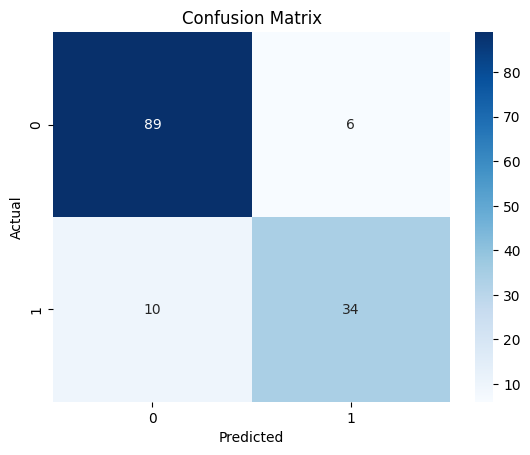

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

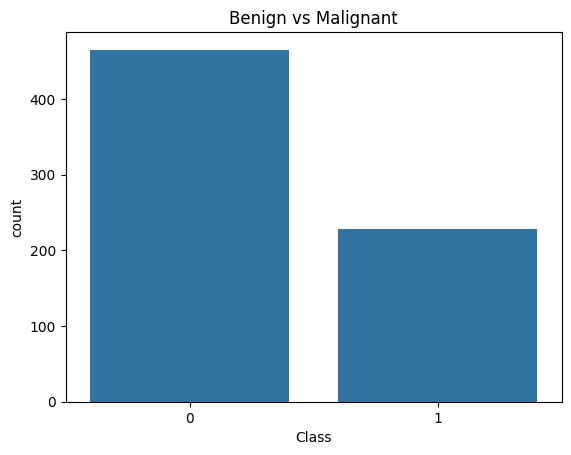

In [ ]:
sns.countplot(x=df["Class"])
plt.title("Benign vs Malignant")
plt.show()

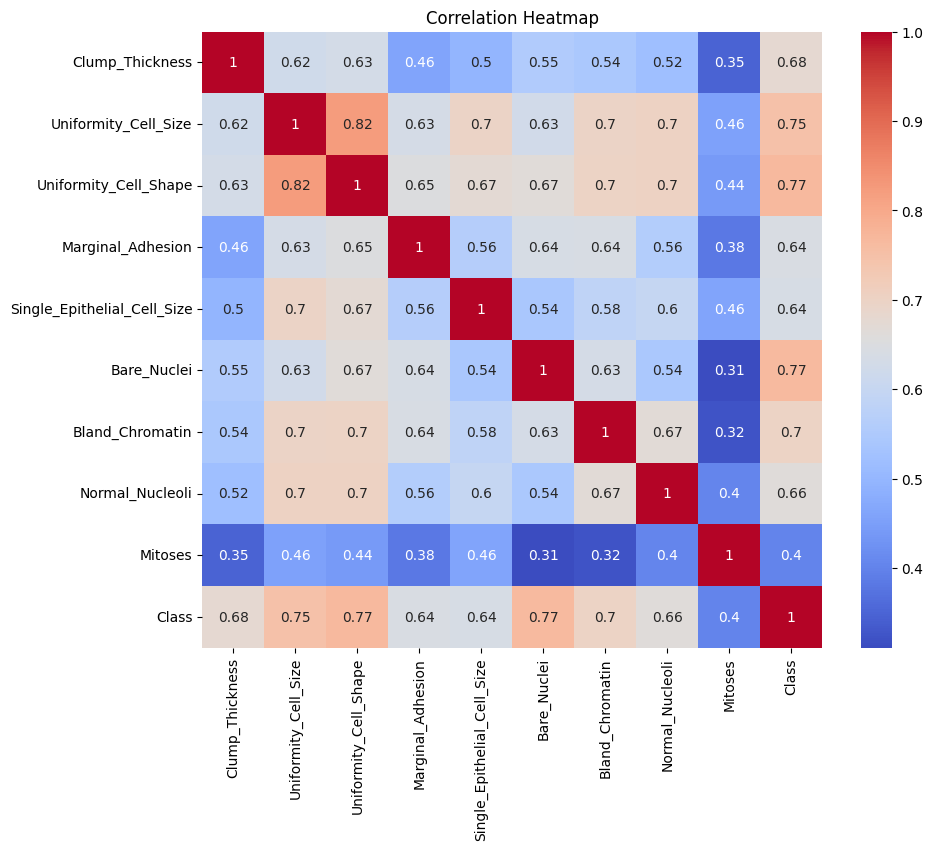

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

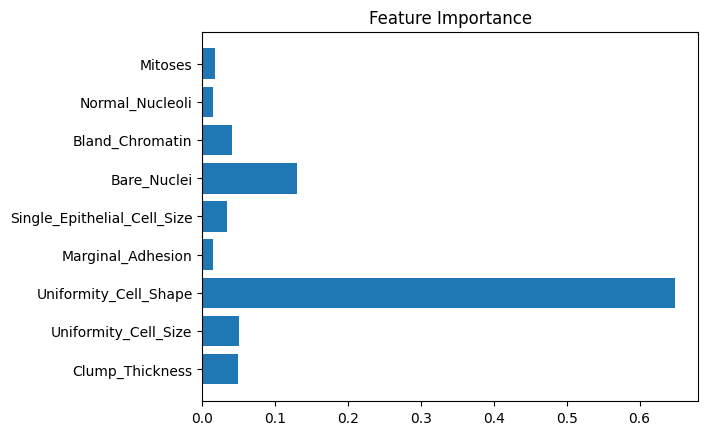

In [ ]:
importance = model.feature_importances_

plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.show()

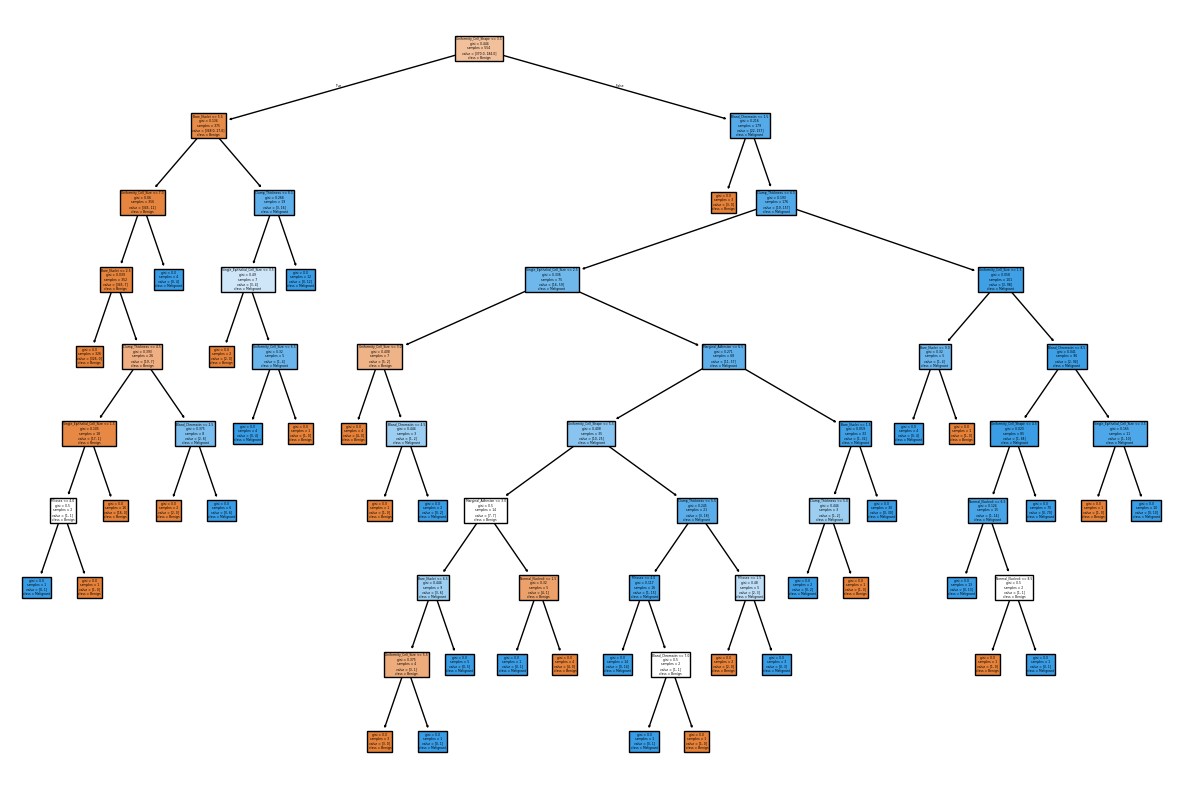

In [ ]:
plt.figure(figsize=(15,10))
plot_tree(model,
          feature_names=X.columns,
          class_names=["Benign", "Malignant"],
          filled=True)

plt.show()

In [ ]:
import pickle

# Save model
pickle.dump(model, open("breast_cancer_model.pkl", "wb"))

print("Model saved successfully")

Model saved successfully
